# ECE 176 Assignment 4: Classification using Neural Network

Now that you have developed and tested your model on the toy dataset set. It's time to get down and get dirty with a standard dataset such as cifar10. At this point, you will be using the provided training data to tune the hyper-parameters of your network such that it works with cifar10 for the task of multi-class classification.

Important: Recall that now we have non-linear decision boundaries, thus we do not need to do one vs all classification. We learn a single non-linear decision boundary instead. Our non-linear boundaries (thanks to relu non-linearity) will take care of differentiating between all the classes

TO SUBMIT: PDF of this notebook with all the required outputs and answers.

## Prepare Datasets

In [1]:
# If you haven't, this command will download the dataset and put it in "./datasets".
!python get_datasets.py

Done


In [2]:
# Prepare Packages
import numpy as np
import matplotlib.pyplot as plt

from utils.data_processing import get_cifar10_data
from utils.evaluation import get_classification_accuracy
from utils.answer import save_answer, dump_answers

answers = {}

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # set default size of plots

# For auto-reloading external modules
# See http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

# Use a subset of CIFAR10 for the assignment
dataset = get_cifar10_data(
    subset_train=5000,
    subset_val=250,
    subset_test=500,
)

print(dataset.keys())
print("Training Set Data  Shape: ", dataset["x_train"].shape)
print("Training Set Label Shape: ", dataset["y_train"].shape)
print("Validation Set Data  Shape: ", dataset["x_val"].shape)
print("Validation Set Label Shape: ", dataset["y_val"].shape)
print("Test Set Data  Shape: ", dataset["x_test"].shape)
print("Test Set Label Shape: ", dataset["y_test"].shape)

dict_keys(['x_train', 'y_train', 'x_val', 'y_val', 'x_test', 'y_test'])
Training Set Data  Shape:  (5000, 3072)
Training Set Label Shape:  (5000,)
Validation Set Data  Shape:  (250, 3072)
Validation Set Label Shape:  (250,)
Test Set Data  Shape:  (500, 3072)
Test Set Label Shape:  (500,)


In [3]:
x_train = dataset["x_train"]
y_train = dataset["y_train"]
x_val = dataset["x_val"]
y_val = dataset["y_val"]
x_test = dataset["x_test"]
y_test = dataset["y_test"]


In [4]:
# Import more utilies and the layers you have implemented
from layers.sequential import Sequential
from layers.linear import Linear
from layers.relu import ReLU
from layers.softmax import Softmax
from layers.loss_func import CrossEntropyLoss
from utils.optimizer import SGD
from utils.dataset import DataLoader
from utils.trainer import Trainer


## Visualize some examples from the dataset.

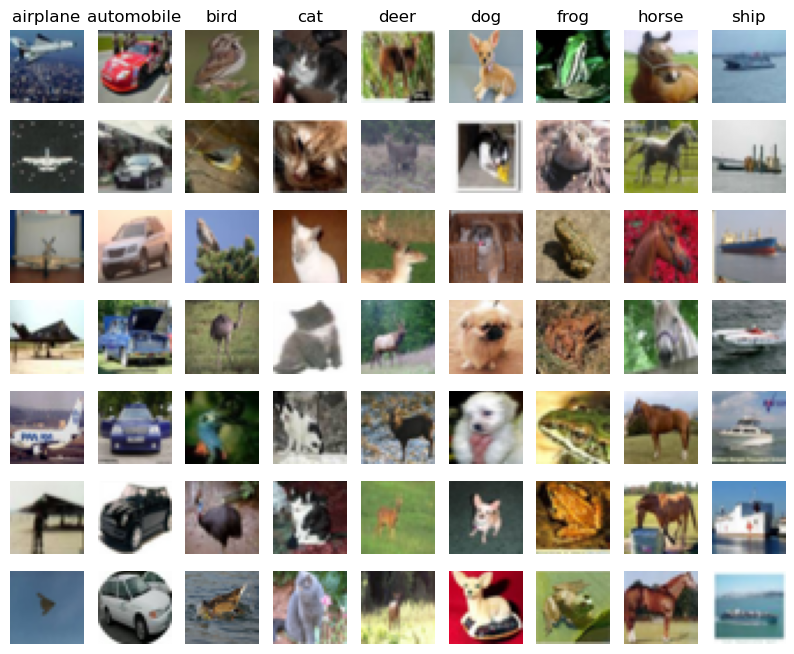

In [5]:
# We show a few examples of training images from each class.
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
]
samples_per_class = 7


def visualize_data(dataset, classes, samples_per_class):
    num_classes = len(classes)
    for y, cls in enumerate(classes):
        idxs = np.flatnonzero(y_train == y)
        idxs = np.random.choice(idxs, samples_per_class, replace=False)
        for i, idx in enumerate(idxs):
            plt_idx = i * num_classes + y + 1
            plt.subplot(samples_per_class, num_classes, plt_idx)
            plt.imshow(dataset[idx])
            plt.axis("off")
            if i == 0:
                plt.title(cls)
    plt.show()


# Visualize the first 10 classes
visualize_data(
    x_train.reshape(5000, 3, 32, 32).transpose(0, 2, 3, 1),
    classes,
    samples_per_class,
)


## Initialize the model

In [6]:
input_size = 3072
hidden_size = 100  # Hidden layer size (Hyper-parameter)
num_classes = 10  # Output

# For a default setting we use the same model we used for the toy dataset.
# This tells you the power of a 2 layered Neural Network. Recall the Universal Approximation Theorem.
# A 2 layer neural network with non-linearities can approximate any function, given large enough hidden layer
def init_model():
    # np.random.seed(0) # No need to fix the seed here
    l1 = Linear(input_size, hidden_size)
    l2 = Linear(hidden_size, num_classes)

    r1 = ReLU()
    softmax = Softmax()
    return Sequential([l1, r1, l2, softmax])


In [7]:
# Initialize the dataset with the dataloader class
dataset = DataLoader(x_train, y_train, x_val, y_val, x_test, y_test)
net = init_model()
optim = SGD(net, lr=0.01, weight_decay=0.01)
loss_func = CrossEntropyLoss()
epoch = 200  # (Hyper-parameter)
batch_size = 200  # (Reduce the batch size if your computer is unable to handle it)


In [8]:
# Initialize the trainer class by passing the above modules
trainer = Trainer(
    dataset, optim, net, loss_func, epoch, batch_size, validate_interval=3
)


In [10]:
# Call the trainer function we have already implemented for you. This trains the model for the given
# hyper-parameters. It follows the same procedure as in the last ipython notebook you used for the toy-dataset
train_error, validation_accuracy = trainer.train()


Epoch Average Loss: 2.302534
Validate Acc: 0.084
Epoch Average Loss: 2.302360
Epoch Average Loss: 2.302155
Epoch Average Loss: 2.301857
Validate Acc: 0.088
Epoch Average Loss: 2.301429
Epoch Average Loss: 2.300824
Epoch Average Loss: 2.299956
Validate Acc: 0.096
Epoch Average Loss: 2.298808
Epoch Average Loss: 2.297280
Epoch Average Loss: 2.295498
Validate Acc: 0.088
Epoch Average Loss: 2.293345
Epoch Average Loss: 2.290830
Epoch Average Loss: 2.287766
Validate Acc: 0.084
Epoch Average Loss: 2.283818
Epoch Average Loss: 2.278784
Epoch Average Loss: 2.272581
Validate Acc: 0.096
Epoch Average Loss: 2.265583
Epoch Average Loss: 2.258157
Epoch Average Loss: 2.250537
Validate Acc: 0.104
Epoch Average Loss: 2.242884
Epoch Average Loss: 2.235457
Epoch Average Loss: 2.228289
Validate Acc: 0.120
Epoch Average Loss: 2.221889
Epoch Average Loss: 2.215692
Epoch Average Loss: 2.209839
Validate Acc: 0.124
Epoch Average Loss: 2.204670
Epoch Average Loss: 2.199843
Epoch Average Loss: 2.195407
Validate

### Print the training and validation accuracies for the default hyper-parameters provided

In [11]:
from utils.evaluation import get_classification_accuracy

out_train = net.predict(x_train)
acc = get_classification_accuracy(out_train, y_train)
print("Training acc: ", acc)
out_val = net.predict(x_val)
acc = get_classification_accuracy(out_val, y_val)
print("Validation acc: ", acc)


Training acc:  0.3502
Validation acc:  0.32


### Debug the training
With the default parameters we provided above, you should get a validation accuracy of around 0.2~0.3 on the validation set. This isn't very good.

One strategy for getting insight into what's wrong is to plot the training loss function and the validation accuracies during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network. In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

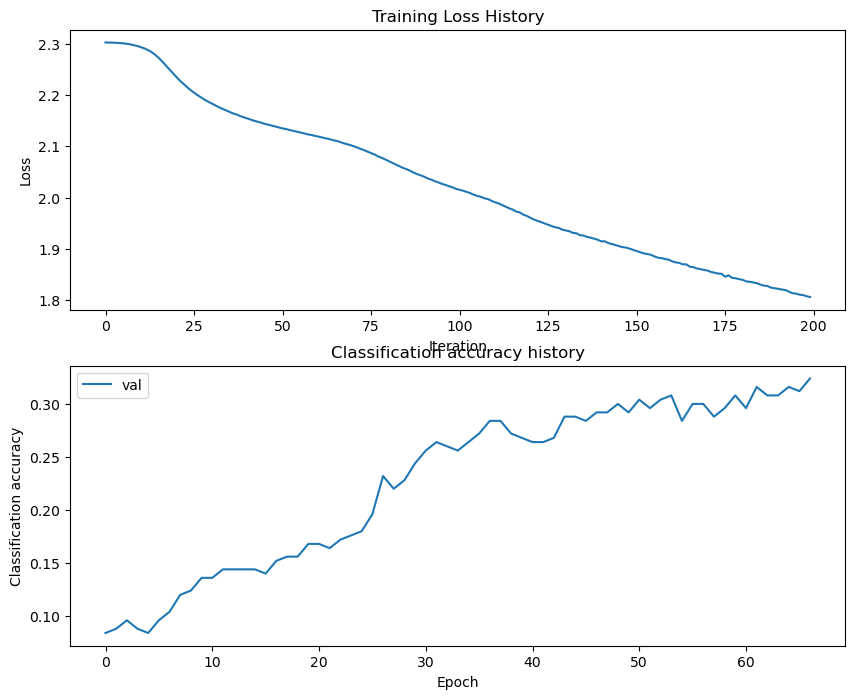

In [12]:
# Plot the training loss function and validation accuracies
plt.subplot(2, 1, 1)
plt.plot(train_error)
plt.title("Training Loss History")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.subplot(2, 1, 2)
# plt.plot(stats['train_acc_history'], label='train')
plt.plot(validation_accuracy, label="val")
plt.title("Classification accuracy history")
plt.xlabel("Epoch")
plt.ylabel("Classification accuracy")
plt.legend()
plt.show()


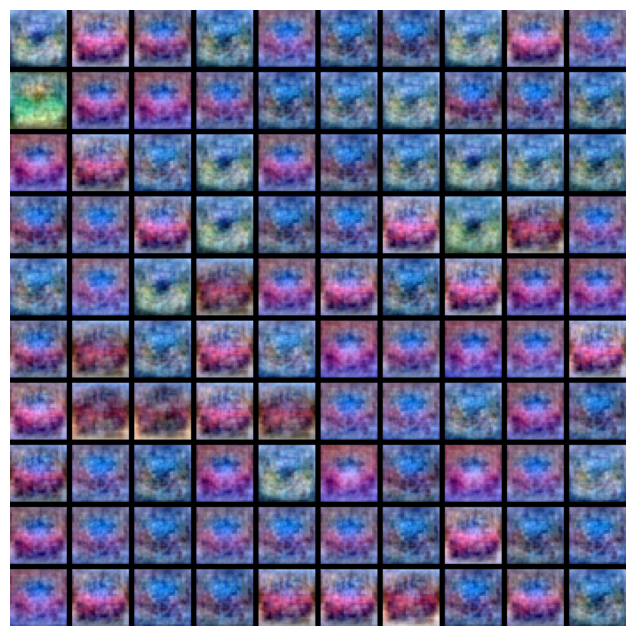

In [13]:
from utils.vis_utils import visualize_grid

# Credits: http://cs231n.stanford.edu/

# Visualize the weights of the network

def show_net_weights(net):
    W1 = net._modules[0].parameters[0]
    W1 = W1.reshape(3, 32, 32, -1).transpose(3, 1, 2, 0)
    plt.imshow(visualize_grid(W1, padding=3).astype("uint8"))
    plt.gca().axis("off")
    plt.show()


show_net_weights(net)


# Tune your hyperparameters (55%)

**What's wrong?**. Looking at the visualizations above, we see that the loss is decreasing more or less linearly, which seems to suggest that the learning rate may be too low. Moreover, there is no gap between the training and validation accuracy, suggesting that the model we used has low capacity, and that we should increase its size. On the other hand, with a very large model we would expect to see more overfitting, which would manifest itself as a very large gap between the training and validation accuracy.

**Tuning**. Tuning the hyperparameters and developing intuition for how they affect the final performance is a large part of using Neural Networks, so we want you to get a lot of practice. Below, you should experiment with different values of the various hyperparameters, including hidden layer size, learning rate, numer of training epochs, and regularization strength.

**Approximate results**. You should be aim to achieve a classification accuracy of greater than 40% on the validation set. Our best network gets over 40% on the validation set.

**Experiment**: You goal in this exercise is to get as good of a result on cifar10 as you can (40% could serve as a reference), with a fully-connected Neural Network.

#### Explain your hyperparameter tuning process below.

#### Your Answer: As suggested, the parimary change was two hyper parameters being learning rate and hidden list. One due to a low learning rate which made changes too small when the network can clearly learn much faster as evident of a linear learning rate. The other plan was the hidden list parameter whcih allows us to expand the amount of neurons in the network which would allow us to find deeper patterns but learn much slower. When running hidden list paarmeters I found my computer was unable to handle the expanded network as learning took a much longer time. I ended up choosing a wider range of learning rates which allowed me to achieve a validation score above 40%. 

In [23]:
#################################################################################
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model hyperparams in best_net.                                                #
#                                                                               #
# To help debug your network, it may help to use visualizations similar to the  #
# ones we used above; these visualizations will have significant qualitative    #
# differences from the ones we saw above for the poorly tuned network.          #
#                                                                               #
# You are now free to test different combinations of hyperparameters to build   #
# various models and test them according to the above plots and visualization   #


# TODO: Show the above plots and visualizations for the default params (already #
# done) and the best hyper-params you obtain. You only need to show this for 2  #
# sets of hyper-params.                                                         #
# You just need to store values for the hyperparameters in best_net_hyperparams #
# as a list in the order
# best_net_hyperparams = [lr, weight_decay, epoch, hidden_size]
#################################################################################
best_net_hyperparams = None
best_net = None
best_train_error = None
best_validation_accuracy = None

best_val = -1

# Try a small set of hyperparams (fast + usually improves accuracy)
lr_list = [0.01, 0.02]
wd_list = [0.001]
epoch_list = [200]
hidden_list = [100]

for lr in lr_list:
    for weight_decay in wd_list:
        for epoch in epoch_list:
            for hidden_size_try in hidden_list:

                # init_model() in your notebook uses the global variable hidden_size
                hidden_size = hidden_size_try

                net_try = init_model()
                optim_try = SGD(net_try, lr=lr, weight_decay=weight_decay)

                trainer_try = Trainer(
                    dataset,
                    optim_try,
                    net_try,
                    loss_func,
                    epoch,
                    batch_size,
                    validate_interval=3
                )

                train_error_try, val_acc_try = trainer_try.train()
                final_val = float(val_acc_try[-1])

                print(f"lr={lr}, wd={weight_decay}, epoch={epoch}, hidden={hidden_size_try} -> val={final_val:.4f}")

                if final_val > best_val:
                    best_val = final_val
                    best_net = net_try
                    best_train_error = train_error_try
                    best_validation_accuracy = val_acc_try
                    best_net_hyperparams = [lr, weight_decay, epoch, hidden_size_try]

print("\nBEST hyperparams:", best_net_hyperparams)
print("BEST validation accuracy:", best_val)


pass


Epoch Average Loss: 2.302540
Validate Acc: 0.084
Epoch Average Loss: 2.302359
Epoch Average Loss: 2.302146
Epoch Average Loss: 2.301849
Validate Acc: 0.104
Epoch Average Loss: 2.301418
Epoch Average Loss: 2.300796
Epoch Average Loss: 2.299915
Validate Acc: 0.096
Epoch Average Loss: 2.298720
Epoch Average Loss: 2.297170
Epoch Average Loss: 2.295344
Validate Acc: 0.084
Epoch Average Loss: 2.293160
Epoch Average Loss: 2.290620
Epoch Average Loss: 2.287438
Validate Acc: 0.084
Epoch Average Loss: 2.283475
Epoch Average Loss: 2.278250
Epoch Average Loss: 2.271851
Validate Acc: 0.096
Epoch Average Loss: 2.264658
Epoch Average Loss: 2.257049
Epoch Average Loss: 2.249283
Validate Acc: 0.100
Epoch Average Loss: 2.241424
Epoch Average Loss: 2.233929
Epoch Average Loss: 2.226829
Validate Acc: 0.120
Epoch Average Loss: 2.220031
Epoch Average Loss: 2.213858
Epoch Average Loss: 2.208102
Validate Acc: 0.124
Epoch Average Loss: 2.202950
Epoch Average Loss: 2.197926
Epoch Average Loss: 2.193578
Validate

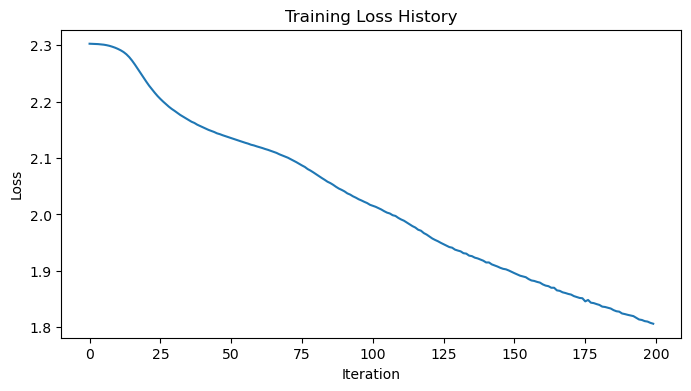

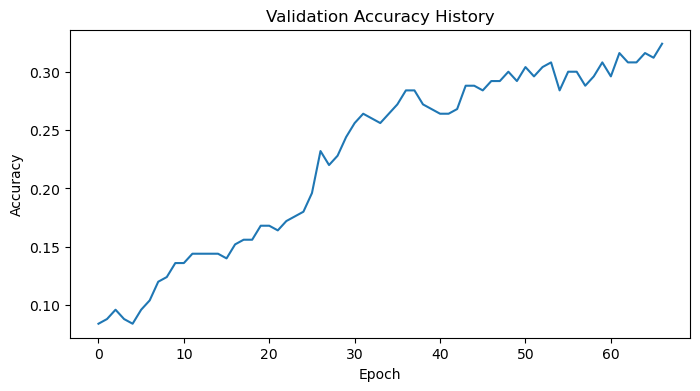

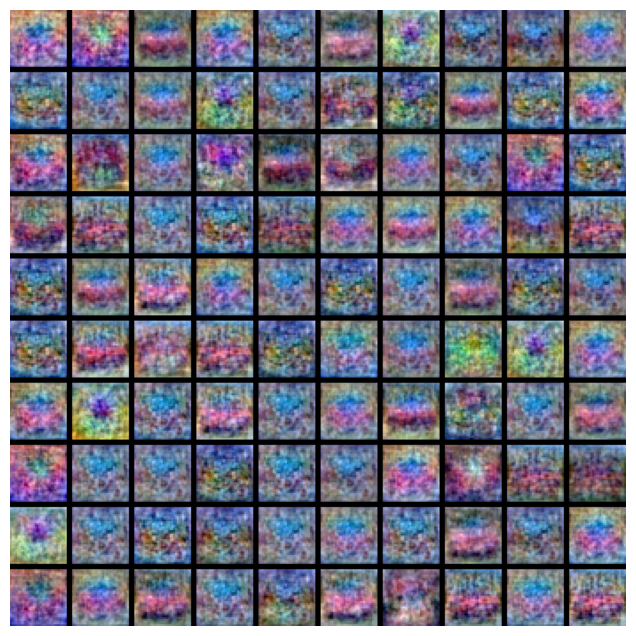

In [24]:
# TODO: Plot the training_error and validation_accuracy of the best network (5%)

# TODO: visualize the weights of the best network (5%)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_error)
plt.title("Training Loss History")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# Plot validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(validation_accuracy)
plt.title("Validation Accuracy History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Visualize weights
show_net_weights(best_net)

# Run on the test set (35%)
When you are done experimenting, you should evaluate your final trained network on the test set; you should get above 35%.

In [25]:
test_acc = (best_net.predict(x_test) == y_test).mean()
print("Test accuracy: ", test_acc)

answers = save_answer(answers, "Q2", test_acc, "float")

Test accuracy:  0.358
[Q2] Saved.


#### Inline Question (10%)

Now that you have trained a Neural Network classifier, you may find that your testing accuracy is much lower than the training accuracy. In what ways can we decrease this gap? Select all that apply.

1. Train on a larger dataset.
2. Add more hidden units.
3. Increase the regularization strength.
4. None of the above.

#### Your Answer:

#### Your Explanation: This is explained by a classic case of overfitting. The model got too comfortbale with the dataset available to it and trained exclusively to this dataset which did not allow it to generalize well outside when presented with new data. The best option of the four is a stronger regularization penalizing the loss function so we don't have too large of weights which would prevent the model from fitting too hard or kind of memorizing the dataset by what is right and wrong. The other option is to train on a larger dataset which would allow the model to tune to larger variation.

## Submitting

### Exporting Answer
We will now export the saved answers to a .txt file. Ensure the answer dictionary is up to date. If unsure, restart the kernel and rerun the notebook before exporting. Do not change the filename here.

In [26]:
dump_answers(
    answers,
    expected_keys=["Q2"],
    filename="answers_hw4.txt"
)

### Exporting Notebook into PDF

Now we will export the current notebook to a PDF file. You can run the cell below. If it fails, you can also export the notebook as a PDF directly from the Jupyter web interface.

> **Note:**  
> Before exporting, make sure you have saved the notebook
> (File → Save Notebook or Cmd/Ctrl + S), then run:

In [27]:
!jupyter nbconvert --to pdf classification_nn.ipynb

[NbConvertApp] Converting notebook classification_nn.ipynb to pdf
[NbConvertApp] Support files will be in classification_nn_files/
[NbConvertApp] Making directory ./classification_nn_files
[NbConvertApp] Writing 79599 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1941062 bytes to classification_nn.pdf


### Submitting to Gradescope

Congrats on finishing **Assignment 4**!

You will see two submission entries on Gradescope: **Assignment 4** and **Assignment 4 – Code**.

- **Assignment 4**  
  Submit `answers_hw4.txt` and the notebook PDF (e.g., `classification_nn.pdf`).  
  No zip file is needed. Upload **one `.txt` file and one `.pdf` file**.

- **Assignment 4 – Code**  
  Submit the `layers/` directory containing your implementations (`linear.py`, `relu.py`, `softmax.py`, `loss_func.py`).  
  This can be a zip file containing the `layers/` folder, or you can upload the files directly.

After you submit **Assignment 4**, you will see format check results. Please make sure that your `answers_hw4.txt` passes all the format checks shown there. If all format checks pass, your submission format is correct and you should be all set.

The **correctness score** will be released later when the assignment scores are officially published.